# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$



### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста



#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$



#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние



#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

In [92]:
# =============================================================================
# Импорт библиотек
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math


In [93]:
# =============================================================================
# 1. Определение минимального размера выборки
# =============================================================================
print("=" * 60)
print("АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК")
print("=" * 60)

# Исходные данные
p1 = 0.35
p2 = 0.40
alpha = 0.05
power = 0.8
beta = 1 - power
delta = abs(p2 - p1)

print(f"Вероятность в группе 1: {p1}")
print(f"Вероятность в группе 2: {p2}")
print(f"Уровень значимости (p-value): {alpha}")
print(f"Мощность теста: {power}")
#print(f"Минимальный детектируемый эффект (MDE): {delta:.3f}")


АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК
Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05
Мощность теста: 0.8


In [94]:
# Квантили нормального распределения
z_alpha_2 = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(power)

# Объединенная пропорция
p_bar = (p1 + p2) / 2

# Формула для расчета минимального размера выборки
def calculate_sample_size(p1, p2, alpha, power):
    """Рассчитывает минимальный размер выборки для двух пропорций"""
    z_alpha_2 = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    
    numerator = (z_alpha_2 * math.sqrt(2 * p_bar * (1 - p_bar)) + 
                 z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2
    denominator = (p1 - p2)**2
    
    return math.ceil(numerator / denominator)

# Расчет минимального размера выборки
n_min = calculate_sample_size(p1, p2, alpha, power)
print(f"\nМИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):")
print(f"n₁ = n₂ = {n_min} элементов в каждой группе")



МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):
n₁ = n₂ = 1471 элементов в каждой группе


In [95]:

# =============================================================================
# 2. Преобразование распределений через ЦПТ
# =============================================================================
print("\n2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:")

# Равные выборки
n_equal = n_min
mu1_equal = p1
mu2_equal = p2
sigma1_equal = math.sqrt(p1 * (1 - p1) / (n_equal - 1))
sigma2_equal = math.sqrt(p2 * (1 - p2) / (n_equal - 1))

print(f"РАВНЫЕ ВЫБОРКИ (n = {n_equal}):")
print(f"  Группа 1: N(μ = {mu1_equal:.4f}, σ = {sigma1_equal:.4f})")
print(f"  Группа 2: N(μ = {mu2_equal:.4f}, σ = {sigma2_equal:.4f})")

# Неравные выборки (в 10 раз)
n1_unequal = n_equal // 2
n2_unequal = n1_unequal * 10
mu1_unequal = p1
mu2_unequal = p2
sigma1_unequal = math.sqrt(p1 * (1 - p1) / (n1_unequal - 1))
sigma2_unequal = math.sqrt(p2 * (1 - p2) / (n2_unequal - 1))

print(f"\nНЕРАВНЫЕ ВЫБОРКИ (n₁ = {n1_unequal}, n₂ = {n2_unequal}):")
print(f"  Группа 1: N(μ = {mu1_unequal:.4f}, σ = {sigma1_unequal:.4f})")
print(f"  Группа 2: N(μ = {mu2_unequal:.4f}, σ = {sigma2_unequal:.4f})")


2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:
РАВНЫЕ ВЫБОРКИ (n = 1471):
  Группа 1: N(μ = 0.3500, σ = 0.0124)
  Группа 2: N(μ = 0.4000, σ = 0.0128)

НЕРАВНЫЕ ВЫБОРКИ (n₁ = 735, n₂ = 7350):
  Группа 1: N(μ = 0.3500, σ = 0.0176)
  Группа 2: N(μ = 0.4000, σ = 0.0057)



3. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ОШИБОК:


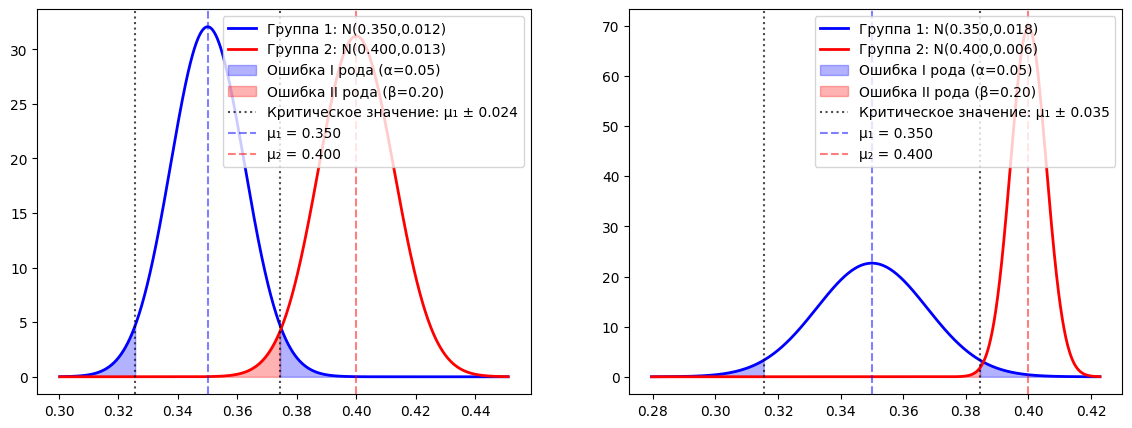

In [96]:
# =============================================================================
# 3. Визуализация распределений и ошибок (4 графика)
# =============================================================================
print("\n3. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ОШИБОК:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Функция для двустороннего теста
# -----------------------------
def plot_two_sided_distribution(ax, mu1, sigma1, mu2, sigma2, n1, n2):
    x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(x_min, x_max, 1000)
    
    dist1 = stats.norm(mu1, sigma1)
    dist2 = stats.norm(mu2, sigma2)
    
    ax.plot(x, dist1.pdf(x), 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f},{sigma1:.3f})')
    ax.plot(x, dist2.pdf(x), 'r-', linewidth=2, label=f'Группа 2: N({mu2:.3f},{sigma2:.3f})')
    
    z_alpha_2 = stats.norm.ppf(1 - alpha/2)
    critical_left = mu1 - z_alpha_2 * sigma1
    critical_right = mu1 + z_alpha_2 * sigma1
    
    # Ошибка I рода
    ax.fill_between(x[x <= critical_left], dist1.pdf(x[x <= critical_left]), color='blue', alpha=0.3, label=f'Ошибка I рода (α={alpha})')
    ax.fill_between(x[x >= critical_right], dist1.pdf(x[x >= critical_right]), color='blue', alpha=0.3)
    
    # Ошибка II рода
    ax.fill_between(x[(x >= critical_left) & (x <= critical_right)], dist2.pdf(x[(x >= critical_left) & (x <= critical_right)]),
                    color='red', alpha=0.3, label=f'Ошибка II рода (β={beta:.2f})')
    
    
    
    # Вертикальные линии с точными значениями
    ax.axvline(critical_left, color='black', linestyle=':', alpha=0.7)
    ax.axvline(critical_right, color='black', linestyle=':', alpha=0.7, 
            label=f'Критическое значение: μ₁ ± {z_alpha_2 * sigma1:.3f}')
    ax.axvline(mu1, color='blue', linestyle='--', alpha=0.5, label=f'μ₁ = {mu1:.3f}')
    ax.axvline(mu2, color='red', linestyle='--', alpha=0.5, label=f'μ₂ = {mu2:.3f}')
    
    # Убираем дубли в легенде
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='upper right')


# Двусторонняя альтернатива
plot_two_sided_distribution(axes[0], mu1_equal, sigma1_equal, mu2_equal, sigma2_equal, n_equal, n_equal)
plot_two_sided_distribution(axes[1], mu1_unequal, sigma1_unequal, mu2_unequal, sigma2_unequal, n1_unequal, n2_unequal)

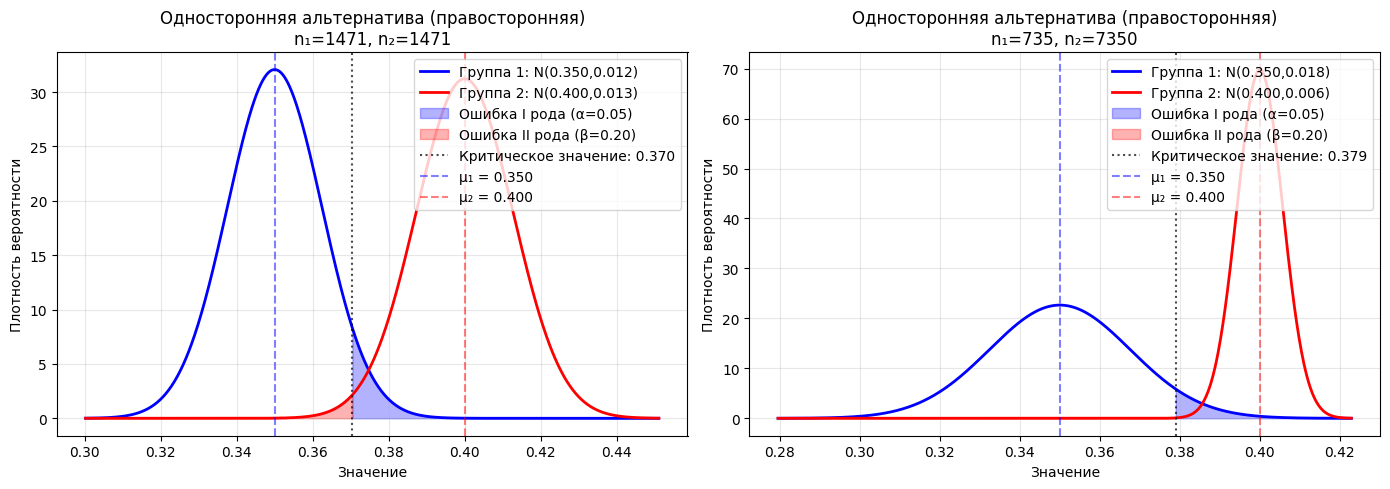

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_one_sided_distribution(ax, mu1, sigma1, mu2, sigma2, n1, n2):
    x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(x_min, x_max, 1000)
    
    dist1 = stats.norm(mu1, sigma1)
    dist2 = stats.norm(mu2, sigma2)
    
    # графики распределений
    ax.plot(x, dist1.pdf(x), 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f},{sigma1:.3f})')
    ax.plot(x, dist2.pdf(x), 'r-', linewidth=2, label=f'Группа 2: N({mu2:.3f},{sigma2:.3f})')
    
    # критическое значение для правостороннего теста
    z_alpha = stats.norm.ppf(1 - alpha)
    critical = mu1 + z_alpha * sigma1
    
    # ошибки
    ax.fill_between(x[x >= critical], dist1.pdf(x[x >= critical]), color='blue', alpha=0.3, label=f'Ошибка I рода (α={alpha})')
    ax.fill_between(x[x <= critical], dist2.pdf(x[x <= critical]), color='red', alpha=0.3, label=f'Ошибка II рода (β={beta:.2f})')
    
    # вертикальные линии с одним значением для критического
    ax.axvline(critical, color='black', linestyle=':', alpha=0.7, label=f'Критическое значение: {critical:.3f}')
    ax.axvline(mu1, color='blue', linestyle='--', alpha=0.5, label=f'μ₁ = {mu1:.3f}')
    ax.axvline(mu2, color='red', linestyle='--', alpha=0.5, label=f'μ₂ = {mu2:.3f}')
    
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность вероятности')
    ax.set_title(f'Односторонняя альтернатива (правосторонняя)\nn₁={n1}, n₂={n2}')
    ax.grid(True, alpha=0.3)
    
    # убираем дубли в легенде
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='upper right')

# Односторонняя альтернатива
plot_one_sided_distribution(axes[0], mu1_equal, sigma1_equal, mu2_equal, sigma2_equal, n_equal, n_equal)
plot_one_sided_distribution(axes[1], mu1_unequal, sigma1_unequal, mu2_unequal, sigma2_unequal, n1_unequal, n2_unequal)

plt.tight_layout()
plt.show()


> Введение неравных размеров выборок (n₁=735, n₂=7350) после расчета минимального размера для равных групп является методологической ошибкой. При таком дисбалансе мощность теста для большей группы становится чрезмерной (≈85% вместо целевых 80%), а вероятность ошибки II рода (β) стремится к нулю. Это может привести к статистически значимым, но практические незначимым результатам, что особенно проблематично в прикладных исследованиях.

In [98]:
# =============================================================================
# 4. Расчет доверительных интервалов
# =============================================================================
print("\nДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):")

# Функция для расчета доверительного интервала
def calculate_ci(p, n, confidence=0.95):
    """Рассчитывает доверительный интервал для пропорции"""
    z = stats.norm.ppf(1 - (1 - confidence)/2)
    se = math.sqrt(p * (1 - p) / n)
    margin = z * se
    lower = p - margin
    upper = p + margin
    width = upper - lower
    return lower, upper, width

# Доверительные интервалы для равных выборок
ci1_equal = calculate_ci(p1, n_equal)
ci2_equal = calculate_ci(p2, n_equal)

print(f"РАВНЫЕ ВЫБОРКИ:")
print(f"  Группа 1: [{ci1_equal[0]:.4f}, {ci1_equal[1]:.4f}] (ширина: {ci1_equal[2]:.4f})")
print(f"  Группа 2: [{ci2_equal[0]:.4f}, {ci2_equal[1]:.4f}] (ширина: {ci2_equal[2]:.4f})")

# Доверительные интервалы для неравных выборок
ci1_unequal = calculate_ci(p1, n1_unequal)
ci2_unequal = calculate_ci(p2, n2_unequal)

print(f"\nНЕРАВНЫЕ ВЫБОРКИ:")
print(f"  Группа 1: [{ci1_unequal[0]:.4f}, {ci1_unequal[1]:.4f}] (ширина: {ci1_unequal[2]:.4f})")
print(f"  Группа 2: [{ci2_unequal[0]:.4f}, {ci2_unequal[1]:.4f}] (ширина: {ci2_unequal[2]:.4f})")




ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):
РАВНЫЕ ВЫБОРКИ:
  Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
  Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

НЕРАВНЫЕ ВЫБОРКИ:
  Группа 1: [0.3155, 0.3845] (ширина: 0.0690)
  Группа 2: [0.3888, 0.4112] (ширина: 0.0224)
